In [2]:
%%time
%load_ext autoreload
%autoreload 2

import pandas as pd
import wandb
import matplotlib.pyplot as plt

# Table processing
def process_line(means, highlight, highlight_index, highlight_max, ignore_std):
    if highlight:
        if highlight_max:
            tops = set(means.groupby(highlight_index).idxmax())
        else:
            tops = set(means.groupby(highlight_index).idxmin())
    else:
        tops = set()

    def process_line(x):
        if ignore_std:
            if x.name in tops:
                return rf"\textbf{{{x['mean']:0.3f}}}"
            return rf"{x['mean']:0.3f}"
        if x.name in tops:
            return rf"\textbf{{{x['mean']:0.3f} $\pm$ {x['std']:0.3f}}}"
        return rf"{x['mean']:0.3f} $\pm$ {x['std']:0.3f}"

    return process_line


def mean_pm_std(
    data,
    index,
    columns,
    value,
    highlight=True,
    highlight_cols=True,
    highlight_max=True,
    ignore_std=False,
):
    assert len(data) > 0
    groupby = data.groupby([*index, *columns])
    means = groupby.mean()[value].rename("mean")
    stds = groupby.std()[value].rename("std")
    ddf = pd.concat([means, stds], axis=1).T
    highlight_index = columns if highlight_cols else index
    ddf = ddf.apply(
        process_line(means, highlight, highlight_index, highlight_max, ignore_std)
    )
    ddf = ddf.reset_index().pivot(index=index, columns=columns)
    ddf.columns = ddf.columns.droplevel(level=0)
    return ddf

    
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def prepare_data(data):
    flattened_data = [flatten_dict(item) for item in data]
    return pd.DataFrame(flattened_data)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 1.92 s, sys: 1 s, total: 2.93 s
Wall time: 12.7 s


In [3]:
api = wandb.Api(timeout=30)

run_name_dict = {
    "tarflow_up_to_4aa_v2": "TarFlow",
    "tarflow_adaptln_up_to_4aa_v2": "TarFlow + AdaptLN/Transition",
    "tarflow_up_to_4aa_pair_bias_small_v3": "TarFlow + Pair Bias",
    "tarflow_up_to_4aa_backbone_v6": "TarFlow + Backbone Perm",
}

run_names = list(run_name_dict.keys())

runs = api.runs(
    "openproblems-comp/self-consume-bg",
    filters={
        "$and": [
            # {"tags": {"$in": ["val_plot_v1"]}},
            {"name": {"$in": run_names}},
        ]
    },
)

summary_list, config_list, name_list, tag_list = [], [], [], []
for run in runs:
    tag_list.append(run.tags)
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)
    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    # .name is the human-readable name of the run.
    name_list.append(run.name)
df_summary = prepare_data(summary_list)
df_config = prepare_data(config_list)
tag_list = [str(t) for t in tag_list]
df = pd.concat(
    [
        pd.DataFrame(name_list, columns=["name"]),
        pd.DataFrame(tag_list, columns=["Tags"]),
        df_summary,
        df_config,
    ],
    axis=1,
)

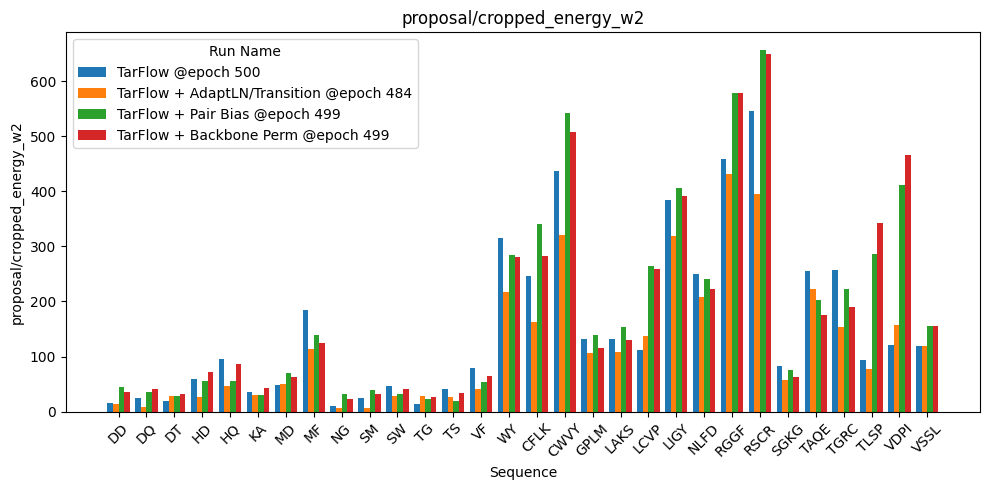

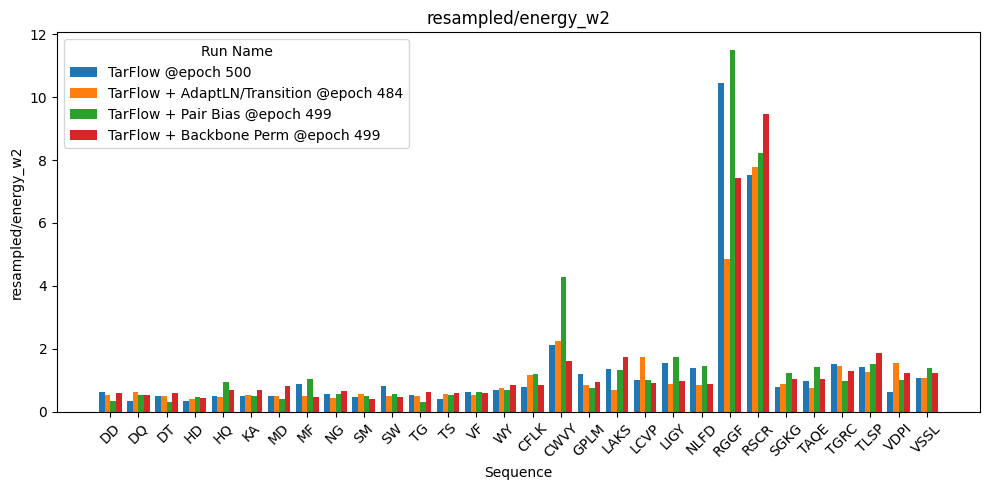

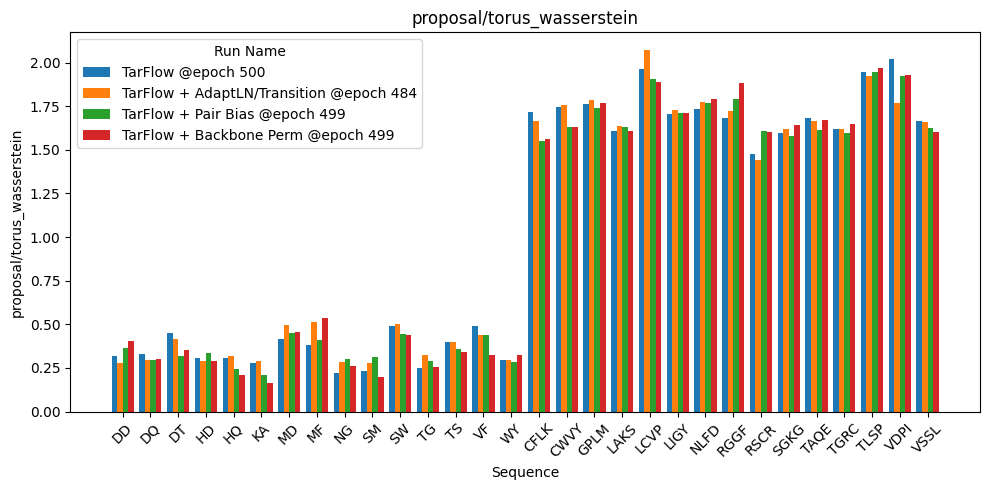

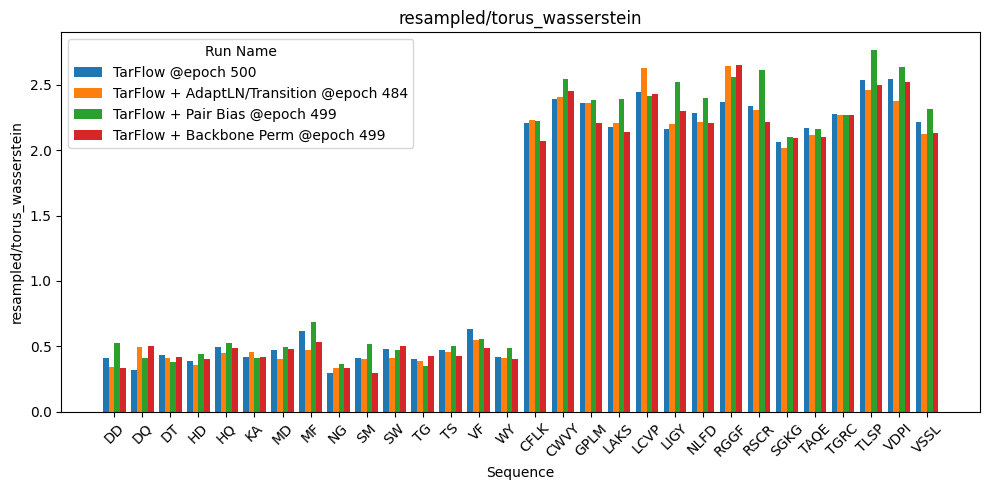

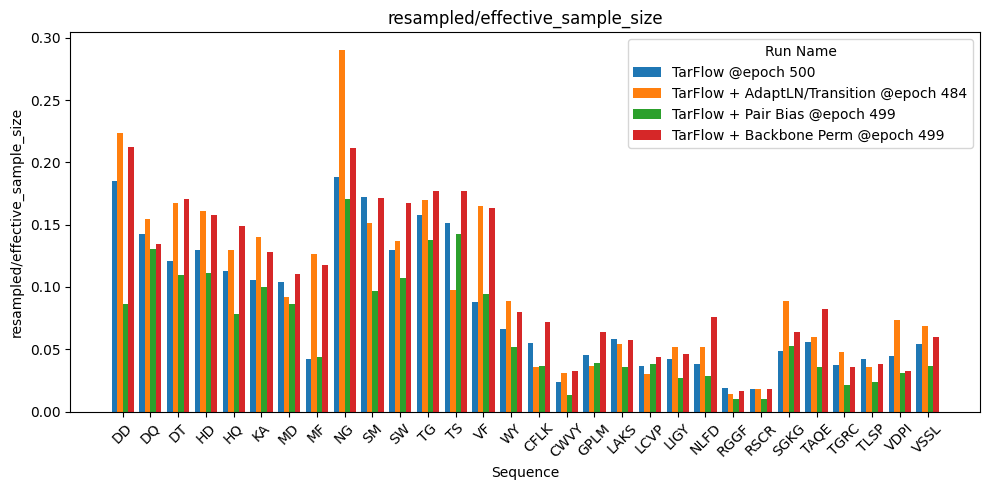

In [4]:
import matplotlib.pyplot as plt
import numpy as np

run_epoch_dict = {}

for metric in [
    "proposal/cropped_energy_w2",
    "resampled/energy_w2",
    "proposal/torus_wasserstein",
    "resampled/torus_wasserstein",
    "resampled/effective_sample_size"
]:
    prefix = "val"
    excluded_keys = {"mean", "median", "count"}

    # First pass: determine all seq_names (shared across runs)
    all_keys = set()
    for run_name in run_names:
        run_df = df[df["name"] == run_name]
        keys = {
            col.split("/")[1]
            for col in run_df.columns
            if col.startswith(prefix) and col.endswith(metric) and len(col.split("/")) >= 4
        }
        run_epoch_dict[run_name] = run_df["epoch"].values[0]
        all_keys.update(keys)

    assert excluded_keys.issubset(all_keys), "Expected keys not found."
    seq_names = sorted(list(all_keys - excluded_keys), key=lambda x: (len(x), x))

    # Data structure: rows = run_names, cols = seq_names
    data = []
    for run_name in run_names:
        run_df = df[df["name"] == run_name]
        column_names = [f"{prefix}/{seq_name}/{metric}" for seq_name in seq_names]
        values = run_df[column_names].iloc[0]
        data.append(values)

    # Plotting
    x = np.arange(len(seq_names))  # positions for seq_names
    total_width = 0.8
    bar_width = total_width / len(run_names)

    plt.figure(figsize=(10, 5))
    for i, (run_name, run_values) in enumerate(zip(run_names, data)):
        offset = (i - len(run_names) / 2) * bar_width + bar_width / 2
        plt.bar(x + offset, run_values, width=bar_width, label=f"{run_name_dict[run_name]} @epoch {run_epoch_dict[run_name]}")

    plt.xticks(x, seq_names, rotation=45)
    plt.xlabel("Sequence")
    plt.ylabel(metric)
    plt.title(f"{metric}")
    plt.legend(title="Run Name")
    plt.tight_layout()
    plt.show()
